# Distributed Optimization Benchmarks

Benchmarks using [decent-bench](https://github.com/team-decent/decent-bench) on quadratic tasks with controlled heterogeneity.

**Algorithms compared:** DGD, GT1, GT2, ADMM

**Experiments:**
1. Algorithm comparison on a fixed task (path graph, moderate δ)
2. Effect of δ (data dissimilarity) on convergence
3. Effect of topology on convergence
4. Nesterov worst-case construction

In [2]:
import numpy as np
import networkx as nx

from decent_bench.cost_functions import QuadraticCost
from decent_bench.benchmark_problem import BenchmarkProblem
from decent_bench.schemes import AlwaysActive, NoCompression, NoNoise, NoDrops
from decent_bench.distributed_algorithms import DGD, GT1, GT2, ADMM
from decent_bench.benchmark import benchmark

## Task Construction

Each quadratic task uses a **shared eigenbasis model**: all nodes share an orthogonal basis Q, but have different eigenvalues.
This means δ = ‖A_i − A_j‖ = ‖diag(λ_i − λ_j)‖ (spectral norm of eigenvalue differences),
cleanly controlled by `delta_scale`.

Library sign convention: f_i(x) = ½ xᵀ A_i x + bᵢᵀx + c_i, so local minimizer x_i\* = −A_i⁻¹ bᵢ.

In [3]:
def make_quadratic_problem(n_agents, dim, delta_scale, topology, seed=42):
    """
    Build a quadratic BenchmarkProblem with controlled data dissimilarity delta.

    Shared-eigenbasis model: A_i = Q diag(lambda_i) Q^T where Q is shared,
    lambda_i are drawn by perturbing a base spectrum by +/- delta_scale.
    Each node's local minimizer x_i* is random; the global optimum is computed exactly.
    """
    rng = np.random.default_rng(seed)

    # Shared orthogonal basis
    Q, _ = np.linalg.qr(rng.standard_normal((dim, dim)))

    # Base spectrum: eigenvalues in [mu, L]
    mu, L = 1.0, 10.0
    base_eigs = np.linspace(mu, L, dim)

    costs = []
    for _ in range(n_agents):
        perturb = rng.uniform(-delta_scale, delta_scale, dim)
        eigs = np.clip(base_eigs + perturb, 0.5, None)
        A_i = Q @ np.diag(eigs) @ Q.T
        x_star_i = rng.standard_normal(dim)   # arbitrary local minimizer
        b_i = -A_i @ x_star_i                 # ensures grad f_i(x_star_i) = 0
        costs.append(QuadraticCost(A_i, b_i, 0.0))

    # Global optimum: solve (sum A_i) x* = -sum b_i
    sum_A = sum(c.A_sym for c in costs)
    sum_b = sum(c.b for c in costs)
    x_star = np.linalg.solve(sum_A, -sum_b)

    return BenchmarkProblem(
        topology_structure=topology,
        optimal_x=x_star,
        cost_functions=costs,
        agent_activation_schemes=[AlwaysActive()] * n_agents,
        compression_scheme=NoCompression(),
        noise_scheme=NoNoise(),
        drop_scheme=NoDrops(),
    )


def make_nesterov_problem(n_agents, mu=0.1, L=10.0, seed=42):
    """
    Nesterov worst-case construction for distributed optimization.

    dim = n_agents. Node i's Hessian is A_i = mu*I + (L-mu)*e_i e_i^T,
    making it effectively rank-1 in the non-regularized part.
    Nodes are connected as a path graph.
    This is the construction that achieves the delta-based lower bound.
    """
    dim = n_agents
    rng = np.random.default_rng(seed)
    costs = []
    for i in range(n_agents):
        e_i = np.zeros(dim)
        e_i[i] = 1.0
        A_i = mu * np.eye(dim) + (L - mu) * np.outer(e_i, e_i)
        x_star_i = rng.standard_normal(dim)
        b_i = -A_i @ x_star_i
        costs.append(QuadraticCost(A_i, b_i, 0.0))

    sum_A = sum(c.A_sym for c in costs)
    sum_b = sum(c.b for c in costs)
    x_star = np.linalg.solve(sum_A, -sum_b)

    return BenchmarkProblem(
        topology_structure=nx.path_graph(n_agents),
        optimal_x=x_star,
        cost_functions=costs,
        agent_activation_schemes=[AlwaysActive()] * n_agents,
        compression_scheme=NoCompression(),
        noise_scheme=NoNoise(),
        drop_scheme=NoDrops(),
    )


def compute_delta(costs):
    """Max pairwise spectral norm of Hessian differences across nodes."""
    hessians = [c.A_sym for c in costs]
    n = len(hessians)
    delta = 0.0
    for i in range(n):
        for j in range(i + 1, n):
            delta = max(delta, np.linalg.norm(hessians[i] - hessians[j], ord=2))
    return delta


def safe_step(costs, fraction=0.8):
    """Conservative step size: fraction / max_local_smoothness."""
    L_max = max(c.m_smooth for c in costs)
    return fraction / L_max

---
## Experiment 1: Algorithm Comparison

Fixed task: 8 nodes, 4-dimensional variable, path graph, moderate δ.

Comparing DGD, GT1, GT2, ADMM. Note that DGD with a fixed step size converges
only to a neighbourhood of the optimum (gradient tracking fixes this).

delta = 3.077,  step_size = 0.0760


[03/27/26 18:44:22] INFO     Starting benchmark execution, progress bar increments with each        ]8;id=368584;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=114008;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#60\60]8;;\
                             completed trial                                                                       

Output()

[03/27/26 18:44:25] INFO     All trials complete                                                    ]8;id=437810;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=833207;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#66\66]8;;\

                    INFO     Table metric definitions can be found here:                       ]8;id=52896;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py\table_metrics.py]8;;\:]8;id=362805;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py#280\280]8;;\
                             https://decent-bench.readthedocs.io/en/latest/api/decent_bench.me                     
                             trics.table_metrics.html                                                              

Output()

                    INFO                                                                       ]8;id=524503;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py\table_metrics.py]8;;\:]8;id=530103;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py#297\297]8;;\
                             +-------------------------------------+----------------------+---                     
                             ------------------+---------------------+---------------------+                       
                             | Metric (statistic)                  | DGD                  |                        
                             GT1                 | GT2                 | ADMM                |                     
                             +=====================================+======================+===                     
                             ==================+=====================+=====================+                       
                             | global cost error                   | 1.26e-01 ± 0.00e+00  |                        
                             0.00e+00 ± 0.00e+00 | 5.29e-13 ± 0.00e+00 | 5.70e-05 ± 0.00e+00 |                     
                             | [<1e-9 = exact conv.] (single)      |                      |                        
                             |                     |                     |                                         
                             +-------------------------------------+----------------------+---                     
                             ------------------+---------------------+---------------------+                       
                             | global gradient optimality (single) | 1.81e-01 ± 0.00e+00  |                        
                             3.71e-23 ± 0.00e+00 | 1.18e-12 ± 0.00e+00 | 1.03e-04 ± 0.00e+00 |                     
                             +-------------------------------------+----------------------+---                     
                             ------------------+---------------------+---------------------+                       
                             | x error (min)                       | 2.28e-01 ± 0.00e+00  |                        
                             7.67e-11 ± 0.00e+00 | 1.53e-06 ± 0.00e+00 | 8.39e-03 ± 0.00e+00 |                     
                             +-------------------------------------+----------------------+---                     
                             ------------------+---------------------+---------------------+                       
                             | x error (avg)                       | 7.05e-01 ± 0.00e+00  |                        
                             9.09e-09 ± 0.00e+00 | 5.62e-06 ± 0.00e+00 | 3.22e-02 ± 0.00e+00 |                     
                             +-------------------------------------+----------------------+---                     
                             ------------------+---------------------+---------------------+                       
                             | x error (max)                       | 1.25e+00 ± 0.00e+00  |                        
                             1.79e-08 ± 0.00e+00 | 8.72e-06 ± 0.00e+00 | 5.01e-02 ± 0.00e+00 |                     
                             +-------------------------------------+----------------------+---                     
                             ------------------+---------------------+---------------------+                       
                             | asymptotic convergence order (avg)  | 1.61e-01 ± 0.00e+00  |                        
                             9.81e-01 ± 0.00e+00 | 1.00e+00 ± 0.00e+00 | 9.94e-01 ± 0.00e+00 |                     
                             +-------------------------------------+--------------------

                    INFO     Plot metric definitions can be found here:                         ]8;id=792598;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/plot_metrics.py\plot_metrics.py]8;;\:]8;id=648794;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/plot_metrics.py#131\131]8;;\
                             https://decent-bench.readthedocs.io/en/latest/api/decent_bench.met                    
                             rics.plot_metrics.html                                                                

Output()

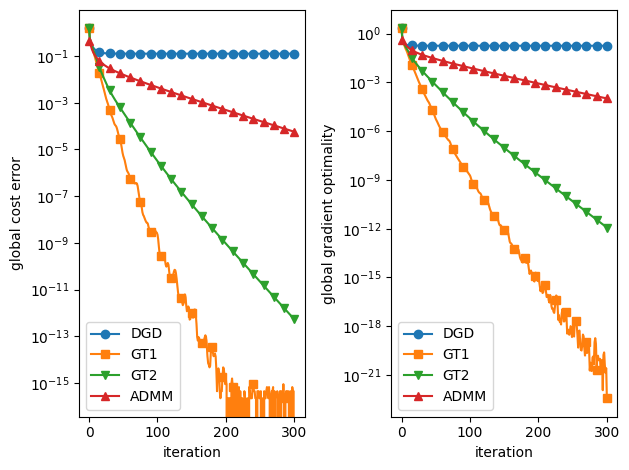

[03/27/26 18:44:27] INFO     Benchmark execution complete, thanks for using decent-bench            ]8;id=613544;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=493799;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#74\74]8;;\

In [4]:
N, D, ITERS = 8, 4, 300

path8 = nx.path_graph(N)
problem_med = make_quadratic_problem(N, D, delta_scale=2.0, topology=path8)

delta_val = compute_delta(problem_med.cost_functions)
step = safe_step(problem_med.cost_functions)
print(f'delta = {delta_val:.3f},  step_size = {step:.4f}')

benchmark(
    algorithms=[
        DGD(ITERS, step),
        GT1(ITERS, step),
        GT2(ITERS, step),
        ADMM(ITERS, rho=1.0, alpha=0.5),
    ],
    benchmark_problem=problem_med,
    n_trials=30,
)

---
## Experiment 2: Effect of δ (Data Dissimilarity)

Fixed algorithm (GT2) and topology (path graph). Three levels of δ.

If the delta-based bound is tight, convergence should degrade monotonically with δ.
Within each δ class, this experiment uses a single random instance — the worst case
under that δ value may be far harder.


--- small  (scale=0.05)  (actual delta = 0.077, step = 0.0799) ---


[03/27/26 18:44:28] INFO     Starting benchmark execution, progress bar increments with each        ]8;id=741621;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=442673;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#60\60]8;;\
                             completed trial                                                                       

Output()

[03/27/26 18:44:30] INFO     All trials complete                                                    ]8;id=577425;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=2616;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#66\66]8;;\

                    INFO     Table metric definitions can be found here:                       ]8;id=373828;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py\table_metrics.py]8;;\:]8;id=818112;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py#280\280]8;;\
                             https://decent-bench.readthedocs.io/en/latest/api/decent_bench.me                     
                             trics.table_metrics.html                                                              

                    INFO                                                                       ]8;id=418048;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py\table_metrics.py]8;;\:]8;id=783667;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py#297\297]8;;\
                             +-------------------------------------+---------------------+                         
                             | Metric (statistic)                  | GT2                 |                         
                             +=====================================+=====================+                         
                             | global cost error                   | 4.11e-15 ± 0.00e+00 |                         
                             | [<1e-9 = exact conv.] (single)      |                     |                         
                             +-------------------------------------+---------------------+                         
                             | global gradient optimality (single) | 1.09e-14 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (min)                       | 6.83e-06 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (avg)                       | 2.25e-05 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (max)                       | 3.44e-05 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | asymptotic convergence order (avg)  | 1.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | asymptotic convergence rate (avg)   | 9.72e-01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | iterative convergence order (avg)   | 2.96e-01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | iterative convergence rate (avg)    | 1.96e+01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr x updates (avg)                  | 3.00e+02 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr x updates (sum)                  | 2.40e+03 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr evaluate calls (avg)             | 0.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr evaluate calls (sum)             | 0.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr gradient calls (avg)             | 3.01e+02 ± 0.00e+00

                    INFO     Plot metric definitions can be found here:                         ]8;id=229707;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/plot_metrics.py\plot_metrics.py]8;;\:]8;id=817976;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/plot_metrics.py#131\131]8;;\
                             https://decent-bench.readthedocs.io/en/latest/api/decent_bench.met                    
                             rics.plot_metrics.html                                                                

Output()

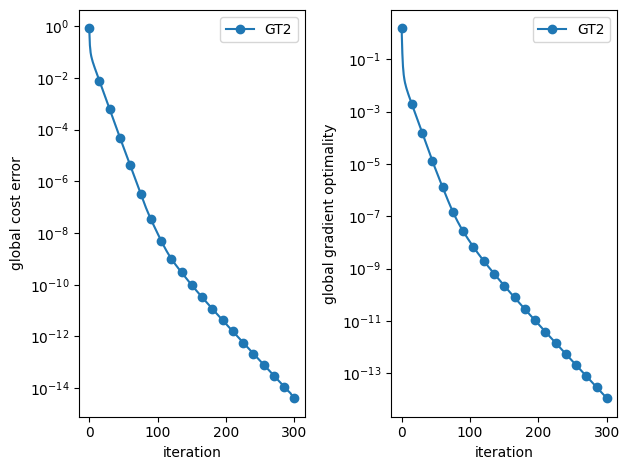

[03/27/26 18:44:31] INFO     Benchmark execution complete, thanks for using decent-bench            ]8;id=29039;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=762831;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#74\74]8;;\


--- medium (scale=1.0)  (actual delta = 1.539, step = 0.0779) ---


[03/27/26 18:44:31] INFO     Starting benchmark execution, progress bar increments with each        ]8;id=10393;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=200403;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#60\60]8;;\
                             completed trial                                                                       

Output()

[03/27/26 18:44:33] INFO     All trials complete                                                    ]8;id=646401;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=851879;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#66\66]8;;\

                    INFO     Table metric definitions can be found here:                       ]8;id=490120;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py\table_metrics.py]8;;\:]8;id=253257;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py#280\280]8;;\
                             https://decent-bench.readthedocs.io/en/latest/api/decent_bench.me                     
                             trics.table_metrics.html                                                              

                    INFO                                                                       ]8;id=989249;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py\table_metrics.py]8;;\:]8;id=845000;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py#297\297]8;;\
                             +-------------------------------------+---------------------+                         
                             | Metric (statistic)                  | GT2                 |                         
                             +=====================================+=====================+                         
                             | global cost error                   | 5.28e-13 ± 0.00e+00 |                         
                             | [<1e-9 = exact conv.] (single)      |                     |                         
                             +-------------------------------------+---------------------+                         
                             | global gradient optimality (single) | 1.25e-12 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (min)                       | 3.42e-06 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (avg)                       | 1.18e-05 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (max)                       | 1.82e-05 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | asymptotic convergence order (avg)  | 1.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | asymptotic convergence rate (avg)   | 9.67e-01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | iterative convergence order (avg)   | 2.79e-01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | iterative convergence rate (avg)    | 1.98e+01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr x updates (avg)                  | 3.00e+02 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr x updates (sum)                  | 2.40e+03 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr evaluate calls (avg)             | 0.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr evaluate calls (sum)             | 0.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr gradient calls (avg)             | 3.01e+02 ± 0.00e+00

                    INFO     Plot metric definitions can be found here:                         ]8;id=807341;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/plot_metrics.py\plot_metrics.py]8;;\:]8;id=286355;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/plot_metrics.py#131\131]8;;\
                             https://decent-bench.readthedocs.io/en/latest/api/decent_bench.met                    
                             rics.plot_metrics.html                                                                

Output()

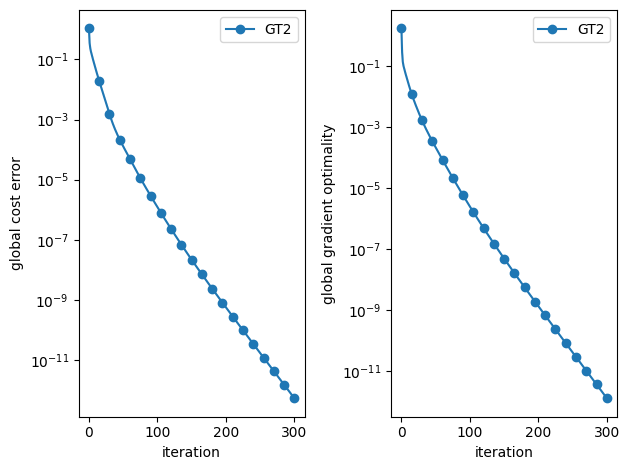

[03/27/26 18:44:34] INFO     Benchmark execution complete, thanks for using decent-bench            ]8;id=405211;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=203131;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#74\74]8;;\


--- large  (scale=4.0)  (actual delta = 6.155, step = 0.0724) ---


[03/27/26 18:44:34] INFO     Starting benchmark execution, progress bar increments with each        ]8;id=413726;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=367267;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#60\60]8;;\
                             completed trial                                                                       

Output()

[03/27/26 18:44:36] INFO     All trials complete                                                    ]8;id=868267;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=187241;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#66\66]8;;\

                    INFO     Table metric definitions can be found here:                       ]8;id=291317;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py\table_metrics.py]8;;\:]8;id=639885;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py#280\280]8;;\
                             https://decent-bench.readthedocs.io/en/latest/api/decent_bench.me                     
                             trics.table_metrics.html                                                              

                    INFO                                                                       ]8;id=715072;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py\table_metrics.py]8;;\:]8;id=326797;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py#297\297]8;;\
                             +-------------------------------------+---------------------+                         
                             | Metric (statistic)                  | GT2                 |                         
                             +=====================================+=====================+                         
                             | global cost error                   | 8.48e-14 ± 0.00e+00 |                         
                             | [<1e-9 = exact conv.] (single)      |                     |                         
                             +-------------------------------------+---------------------+                         
                             | global gradient optimality (single) | 1.67e-13 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (min)                       | 2.32e-07 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (avg)                       | 1.00e-06 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (max)                       | 1.59e-06 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | asymptotic convergence order (avg)  | 1.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | asymptotic convergence rate (avg)   | 9.53e-01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | iterative convergence order (avg)   | 2.26e-01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | iterative convergence rate (avg)    | 2.07e+01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr x updates (avg)                  | 3.00e+02 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr x updates (sum)                  | 2.40e+03 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr evaluate calls (avg)             | 0.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr evaluate calls (sum)             | 0.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr gradient calls (avg)             | 3.01e+02 ± 0.00e+00

                    INFO     Plot metric definitions can be found here:                         ]8;id=618492;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/plot_metrics.py\plot_metrics.py]8;;\:]8;id=839767;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/plot_metrics.py#131\131]8;;\
                             https://decent-bench.readthedocs.io/en/latest/api/decent_bench.met                    
                             rics.plot_metrics.html                                                                

Output()

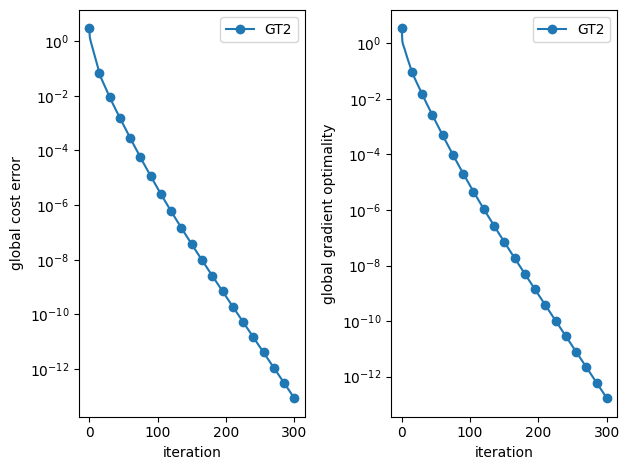

[03/27/26 18:44:37] INFO     Benchmark execution complete, thanks for using decent-bench            ]8;id=359478;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=768540;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#74\74]8;;\

In [5]:
delta_configs = [
    ('small  (scale=0.05)', 0.05),
    ('medium (scale=1.0)',  1.0),
    ('large  (scale=4.0)',  4.0),
]

for label, scale in delta_configs:
    p = make_quadratic_problem(N, D, delta_scale=scale, topology=path8)
    d = compute_delta(p.cost_functions)
    s = safe_step(p.cost_functions)
    print(f'\n--- {label}  (actual delta = {d:.3f}, step = {s:.4f}) ---')
    benchmark(
        algorithms=[GT2(ITERS, s)],
        benchmark_problem=p,
        n_trials=30,
    )

---
## Experiment 3: Effect of Graph Topology

Fixed algorithm (GT2) and δ. Four topologies on 8 nodes:
- **Path** — worst connectivity, spectral gap ∝ 1/N²
- **Cycle** — slightly better, spectral gap ∝ 1/N²  
- **Random regular (d=3)** — expander-like, spectral gap O(1)
- **Complete** — best connectivity, no topology bottleneck

The beyond-spectral-gap papers argue that spectral gap alone doesn't predict
convergence — this experiment provides an empirical check.


--- Path graph  (delta = 1.539, step = 0.0779) ---


[03/27/26 18:44:37] INFO     Starting benchmark execution, progress bar increments with each        ]8;id=38692;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=251999;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#60\60]8;;\
                             completed trial                                                                       

Output()

[03/27/26 18:44:40] INFO     All trials complete                                                    ]8;id=345666;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=238415;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#66\66]8;;\

                    INFO     Table metric definitions can be found here:                       ]8;id=754165;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py\table_metrics.py]8;;\:]8;id=853142;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py#280\280]8;;\
                             https://decent-bench.readthedocs.io/en/latest/api/decent_bench.me                     
                             trics.table_metrics.html                                                              

                    INFO                                                                       ]8;id=842944;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py\table_metrics.py]8;;\:]8;id=586381;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py#297\297]8;;\
                             +-------------------------------------+---------------------+                         
                             | Metric (statistic)                  | GT2                 |                         
                             +=====================================+=====================+                         
                             | global cost error                   | 5.28e-13 ± 0.00e+00 |                         
                             | [<1e-9 = exact conv.] (single)      |                     |                         
                             +-------------------------------------+---------------------+                         
                             | global gradient optimality (single) | 1.25e-12 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (min)                       | 3.42e-06 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (avg)                       | 1.18e-05 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (max)                       | 1.82e-05 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | asymptotic convergence order (avg)  | 1.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | asymptotic convergence rate (avg)   | 9.67e-01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | iterative convergence order (avg)   | 2.79e-01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | iterative convergence rate (avg)    | 1.98e+01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr x updates (avg)                  | 3.00e+02 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr x updates (sum)                  | 2.40e+03 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr evaluate calls (avg)             | 0.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr evaluate calls (sum)             | 0.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr gradient calls (avg)             | 3.01e+02 ± 0.00e+00

                    INFO     Plot metric definitions can be found here:                         ]8;id=971700;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/plot_metrics.py\plot_metrics.py]8;;\:]8;id=119551;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/plot_metrics.py#131\131]8;;\
                             https://decent-bench.readthedocs.io/en/latest/api/decent_bench.met                    
                             rics.plot_metrics.html                                                                

Output()

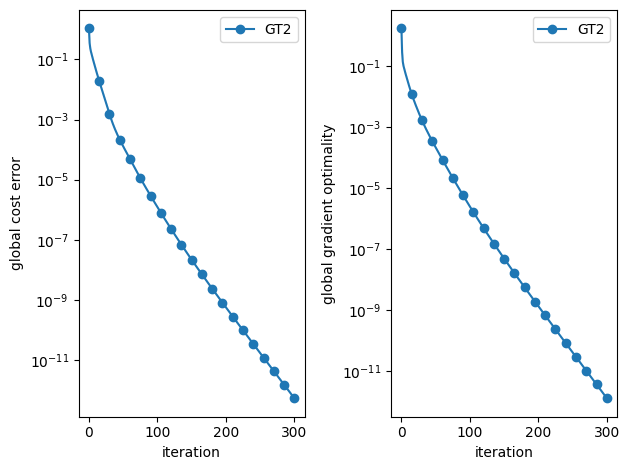

                    INFO     Benchmark execution complete, thanks for using decent-bench            ]8;id=781551;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=69716;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#74\74]8;;\


--- Cycle graph  (delta = 1.539, step = 0.0779) ---


[03/27/26 18:44:40] INFO     Starting benchmark execution, progress bar increments with each        ]8;id=609593;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=738024;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#60\60]8;;\
                             completed trial                                                                       

Output()

[03/27/26 18:44:42] INFO     All trials complete                                                    ]8;id=640724;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=491718;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#66\66]8;;\

                    INFO     Table metric definitions can be found here:                       ]8;id=846756;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py\table_metrics.py]8;;\:]8;id=669727;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py#280\280]8;;\
                             https://decent-bench.readthedocs.io/en/latest/api/decent_bench.me                     
                             trics.table_metrics.html                                                              

                    INFO                                                                       ]8;id=919494;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py\table_metrics.py]8;;\:]8;id=798686;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py#297\297]8;;\
                             +-------------------------------------+---------------------+                         
                             | Metric (statistic)                  | GT2                 |                         
                             +=====================================+=====================+                         
                             | global cost error                   | 4.44e-16 ± 0.00e+00 |                         
                             | [<1e-9 = exact conv.] (single)      |                     |                         
                             +-------------------------------------+---------------------+                         
                             | global gradient optimality (single) | 2.31e-27 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (min)                       | 1.16e-14 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (avg)                       | 1.45e-14 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (max)                       | 1.79e-14 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | asymptotic convergence order (avg)  | 1.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | asymptotic convergence rate (avg)   | 9.13e-01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | iterative convergence order (avg)   | 9.96e-02 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | iterative convergence rate (avg)    | 2.27e+01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr x updates (avg)                  | 3.00e+02 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr x updates (sum)                  | 2.40e+03 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr evaluate calls (avg)             | 0.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr evaluate calls (sum)             | 0.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr gradient calls (avg)             | 3.01e+02 ± 0.00e+00

                    INFO     Plot metric definitions can be found here:                         ]8;id=990076;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/plot_metrics.py\plot_metrics.py]8;;\:]8;id=963220;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/plot_metrics.py#131\131]8;;\
                             https://decent-bench.readthedocs.io/en/latest/api/decent_bench.met                    
                             rics.plot_metrics.html                                                                

Output()

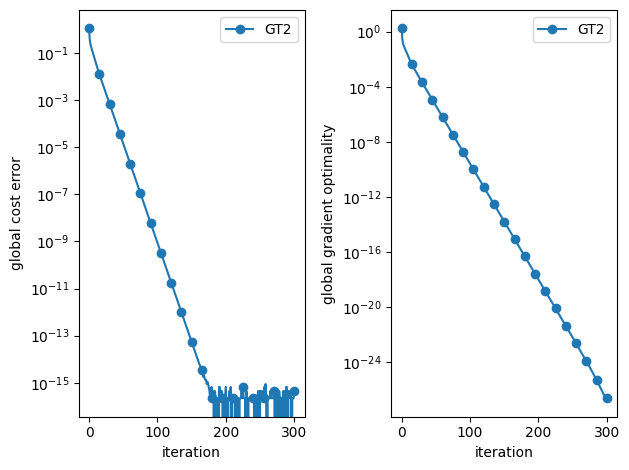

[03/27/26 18:44:43] INFO     Benchmark execution complete, thanks for using decent-bench            ]8;id=619427;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=48815;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#74\74]8;;\


--- Random regular (d=3)  (delta = 1.539, step = 0.0779) ---


[03/27/26 18:44:43] INFO     Starting benchmark execution, progress bar increments with each        ]8;id=160912;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=702504;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#60\60]8;;\
                             completed trial                                                                       

Output()

[03/27/26 18:44:45] INFO     All trials complete                                                    ]8;id=44264;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=861754;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#66\66]8;;\

                    INFO     Table metric definitions can be found here:                       ]8;id=150829;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py\table_metrics.py]8;;\:]8;id=510723;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py#280\280]8;;\
                             https://decent-bench.readthedocs.io/en/latest/api/decent_bench.me                     
                             trics.table_metrics.html                                                              

                    INFO                                                                       ]8;id=244458;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py\table_metrics.py]8;;\:]8;id=93606;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py#297\297]8;;\
                             +-------------------------------------+---------------------+                         
                             | Metric (statistic)                  | GT2                 |                         
                             +=====================================+=====================+                         
                             | global cost error                   | 2.22e-16 ± 0.00e+00 |                         
                             | [<1e-9 = exact conv.] (single)      |                     |                         
                             +-------------------------------------+---------------------+                         
                             | global gradient optimality (single) | 4.18e-27 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (min)                       | 5.39e-14 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (avg)                       | 5.45e-14 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (max)                       | 5.52e-14 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | asymptotic convergence order (avg)  | 1.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | asymptotic convergence rate (avg)   | 9.05e-01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | iterative convergence order (avg)   | 1.01e-01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | iterative convergence rate (avg)    | 2.22e+01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr x updates (avg)                  | 3.00e+02 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr x updates (sum)                  | 2.40e+03 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr evaluate calls (avg)             | 0.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr evaluate calls (sum)             | 0.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr gradient calls (avg)             | 3.01e+02 ± 0.00e+00 

                    INFO     Plot metric definitions can be found here:                         ]8;id=88051;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/plot_metrics.py\plot_metrics.py]8;;\:]8;id=182048;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/plot_metrics.py#131\131]8;;\
                             https://decent-bench.readthedocs.io/en/latest/api/decent_bench.met                    
                             rics.plot_metrics.html                                                                

Output()

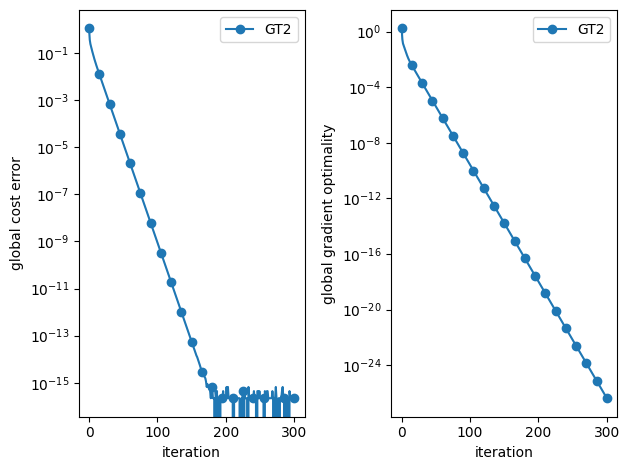

[03/27/26 18:44:46] INFO     Benchmark execution complete, thanks for using decent-bench            ]8;id=294736;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=782412;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#74\74]8;;\


--- Complete graph  (delta = 1.539, step = 0.0779) ---


[03/27/26 18:44:46] INFO     Starting benchmark execution, progress bar increments with each        ]8;id=24338;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=848332;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#60\60]8;;\
                             completed trial                                                                       

Output()

[03/27/26 18:44:49] INFO     All trials complete                                                    ]8;id=306955;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=480618;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#66\66]8;;\

                    INFO     Table metric definitions can be found here:                       ]8;id=704282;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py\table_metrics.py]8;;\:]8;id=427689;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py#280\280]8;;\
                             https://decent-bench.readthedocs.io/en/latest/api/decent_bench.me                     
                             trics.table_metrics.html                                                              

                    INFO                                                                       ]8;id=212797;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py\table_metrics.py]8;;\:]8;id=809860;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py#297\297]8;;\
                             +-------------------------------------+---------------------+                         
                             | Metric (statistic)                  | GT2                 |                         
                             +=====================================+=====================+                         
                             | global cost error                   | 4.44e-16 ± 0.00e+00 |                         
                             | [<1e-9 = exact conv.] (single)      |                     |                         
                             +-------------------------------------+---------------------+                         
                             | global gradient optimality (single) | 4.69e-27 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (min)                       | 5.75e-14 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (avg)                       | 5.78e-14 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | x error (max)                       | 5.80e-14 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | asymptotic convergence order (avg)  | 1.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | asymptotic convergence rate (avg)   | 9.04e-01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | iterative convergence order (avg)   | 1.01e-01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | iterative convergence rate (avg)    | 2.21e+01 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr x updates (avg)                  | 3.00e+02 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr x updates (sum)                  | 2.40e+03 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr evaluate calls (avg)             | 0.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr evaluate calls (sum)             | 0.00e+00 ± 0.00e+00 |                         
                             +-------------------------------------+---------------------+                         
                             | nr gradient calls (avg)             | 3.01e+02 ± 0.00e+00

                    INFO     Plot metric definitions can be found here:                         ]8;id=480368;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/plot_metrics.py\plot_metrics.py]8;;\:]8;id=782217;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/plot_metrics.py#131\131]8;;\
                             https://decent-bench.readthedocs.io/en/latest/api/decent_bench.met                    
                             rics.plot_metrics.html                                                                

Output()

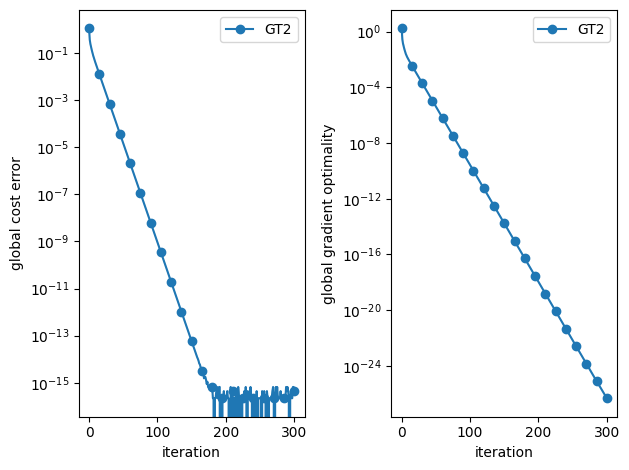

                    INFO     Benchmark execution complete, thanks for using decent-bench            ]8;id=469054;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=947574;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#74\74]8;;\

In [6]:
topologies = [
    ('Path graph',            nx.path_graph(N)),
    ('Cycle graph',           nx.cycle_graph(N)),
    ('Random regular (d=3)',  nx.random_regular_graph(3, N, seed=0)),
    ('Complete graph',        nx.complete_graph(N)),
]

for label, topo in topologies:
    p = make_quadratic_problem(N, D, delta_scale=1.0, topology=topo, seed=42)
    s = safe_step(p.cost_functions)
    d = compute_delta(p.cost_functions)
    print(f'\n--- {label}  (delta = {d:.3f}, step = {s:.4f}) ---')
    benchmark(
        algorithms=[GT2(ITERS, s)],
        benchmark_problem=p,
        n_trials=30,
    )

---
## Experiment 4: Nesterov Worst-Case Construction

The construction that achieves the δ lower bound.
Node i holds A_i = μI + (L−μ) eᵢ eᵢᵀ — a rank-1 "spike" in coordinate i
plus a small regularization μI. Nodes are connected as a path.

δ = ‖A_i − A_j‖ ≈ L − μ (all pairs have the same large difference).
This is deliberately maximally heterogeneous in the worst possible structure.

Compare convergence here against Experiment 1 which has similar δ but is a
random instance — this quantifies the gap between worst-case and typical.

Nesterov construction: delta = 9.900,  step = 0.0800


[03/27/26 18:44:49] INFO     Starting benchmark execution, progress bar increments with each        ]8;id=213400;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=836331;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#60\60]8;;\
                             completed trial                                                                       

Output()

[03/27/26 18:44:53] INFO     All trials complete                                                    ]8;id=526261;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=335294;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#66\66]8;;\

                    INFO     Table metric definitions can be found here:                       ]8;id=149254;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py\table_metrics.py]8;;\:]8;id=99179;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py#280\280]8;;\
                             https://decent-bench.readthedocs.io/en/latest/api/decent_bench.me                     
                             trics.table_metrics.html                                                              

Output()

                    INFO                                                                       ]8;id=177570;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py\table_metrics.py]8;;\:]8;id=647991;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/table_metrics.py#297\297]8;;\
                             +-------------------------------------+---------------------+----                     
                             -----------------+---------------------+---------------------+                        
                             | Metric (statistic)                  | DGD                 | GT1                     
                             | GT2                 | ADMM                |                                         
                             +=====================================+=====================+====                     
                             =================+=====================+=====================+                        
                             | global cost error                   | 7.49e-01 ± 0.00e+00 |                         
                             8.15e-08 ± 0.00e+00 | 1.30e-13 ± 0.00e+00 | 1.78e-15 ± 0.00e+00 |                     
                             | [<1e-9 = exact conv.] (single)      |                     |                         
                             |                     |                     |                                         
                             +-------------------------------------+---------------------+----                     
                             -----------------+---------------------+---------------------+                        
                             | global gradient optimality (single) | 2.50e-01 ± 0.00e+00 |                         
                             2.72e-08 ± 0.00e+00 | 4.26e-14 ± 0.00e+00 | 3.54e-19 ± 0.00e+00 |                     
                             +-------------------------------------+---------------------+----                     
                             -----------------+---------------------+---------------------+                        
                             | x error (min)                       | 3.85e-01 ± 0.00e+00 |                         
                             5.14e-04 ± 0.00e+00 | 5.20e-07 ± 0.00e+00 | 4.14e-10 ± 0.00e+00 |                     
                             +-------------------------------------+---------------------+----                     
                             -----------------+---------------------+---------------------+                        
                             | x error (avg)                       | 4.66e-01 ± 0.00e+00 |                         
                             1.10e-03 ± 0.00e+00 | 1.94e-06 ± 0.00e+00 | 5.27e-10 ± 0.00e+00 |                     
                             +-------------------------------------+---------------------+----                     
                             -----------------+---------------------+---------------------+                        
                             | x error (max)                       | 5.34e-01 ± 0.00e+00 |                         
                             1.32e-03 ± 0.00e+00 | 3.15e-06 ± 0.00e+00 | 6.49e-10 ± 0.00e+00 |                     
                             +-------------------------------------+---------------------+----                     
                             -----------------+---------------------+---------------------+                        
                             | asymptotic convergence order (avg)  | 9.65e-01 ± 0.00e+00 |                         
                             9.66e-01 ± 0.00e+00 | 9.96e-01 ± 0.00e+00 | 9.99e-01 ± 0.00e+00 |                     
                             +-------------------------------------+--------------------

                    INFO     Plot metric definitions can be found here:                         ]8;id=342874;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/plot_metrics.py\plot_metrics.py]8;;\:]8;id=420611;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/metrics/plot_metrics.py#131\131]8;;\
                             https://decent-bench.readthedocs.io/en/latest/api/decent_bench.met                    
                             rics.plot_metrics.html                                                                

Output()

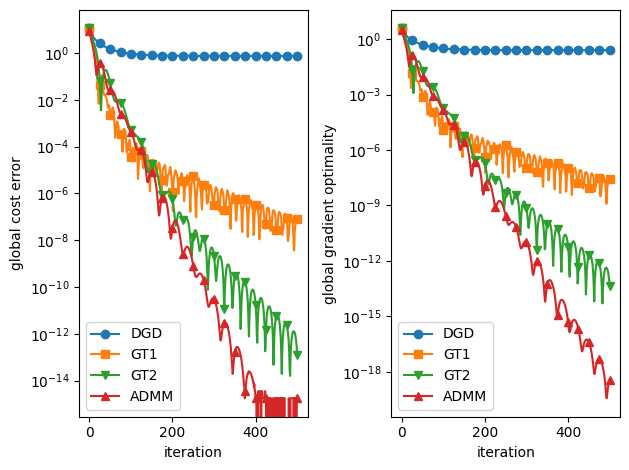

[03/27/26 18:44:56] INFO     Benchmark execution complete, thanks for using decent-bench            ]8;id=774665;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py\benchmark.py]8;;\:]8;id=142022;file:///Users/a2mogus/Documents/distributed_learning_project/.venv/lib/python3.13/site-packages/decent_bench/benchmark.py#74\74]8;;\

In [7]:
ITERS_NESTEROV = 500

problem_nesterov = make_nesterov_problem(n_agents=N, mu=0.1, L=10.0)
delta_n = compute_delta(problem_nesterov.cost_functions)
step_n = safe_step(problem_nesterov.cost_functions)
print(f'Nesterov construction: delta = {delta_n:.3f},  step = {step_n:.4f}')

benchmark(
    algorithms=[
        DGD(ITERS_NESTEROV, step_n),
        GT1(ITERS_NESTEROV, step_n),
        GT2(ITERS_NESTEROV, step_n),
        ADMM(ITERS_NESTEROV, rho=1.0, alpha=0.5),
    ],
    benchmark_problem=problem_nesterov,
    n_trials=30,
)